--- STEP 1: LOADING DATASET & EDA ---
Dataset Shape: (1599, 12)

--- Missing Value Check ---
Total Missing Values: 0

--- Quality Score Counts (Original) ---
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


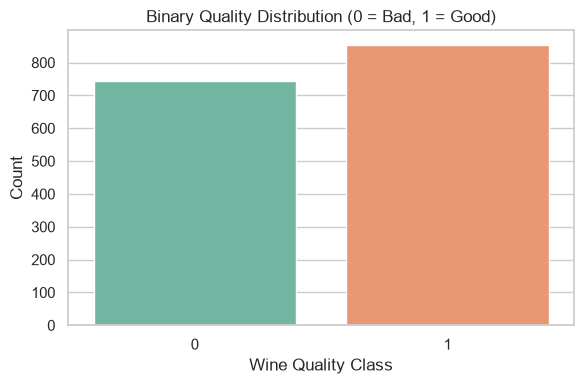

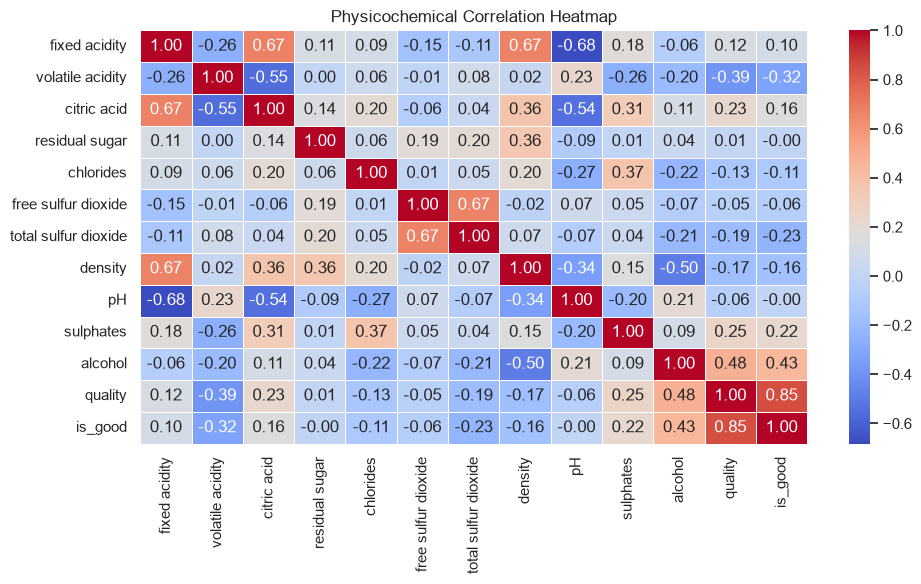


--- STEP 5: MODEL PERFORMANCE EVALUATION ---
              Model  Accuracy  Precision  Recall  F1-Score
Logistic Regression    0.7406     0.7683  0.7368    0.7522
      Decision Tree    0.7281     0.7530  0.7310    0.7418
      Random Forest    0.8031     0.8293  0.7953    0.8119


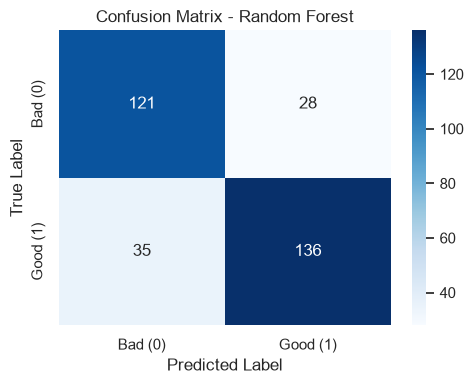

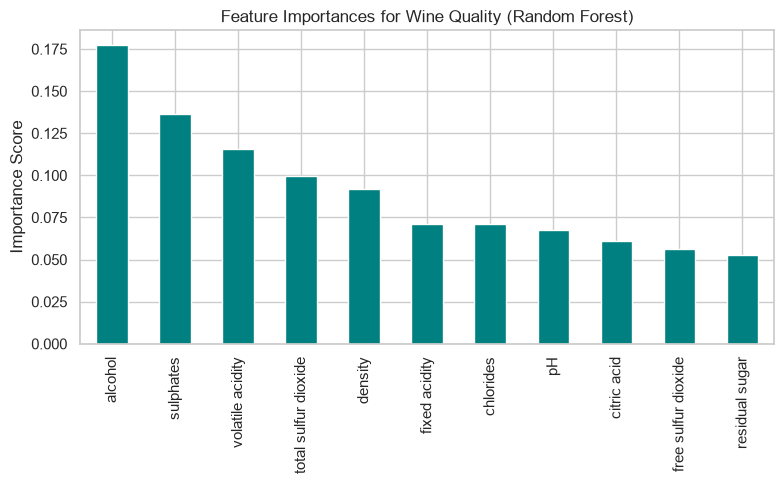

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Set style
sns.set_theme(style="whitegrid")

# ==========================================
# 1. LOAD DATASET & EDA
# ==========================================
print("--- STEP 1: LOADING DATASET & EDA ---")
# Load Red Wine Quality dataset directly from official UCI URL
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
df = pd.read_csv(url, sep=';')

print(f"Dataset Shape: {df.shape}")
print("\n--- Missing Value Check ---")
print(f"Total Missing Values: {df.isnull().sum().sum()}")

print("\n--- Quality Score Counts (Original) ---")
print(df['quality'].value_counts().sort_index())

# ==========================================
# 2. BINARY TARGET CREATION
# ==========================================
# Quality >= 6 -> Good (1), Quality < 6 -> Bad (0)
df['is_good'] = (df['quality'] >= 6).astype(int)

plt.figure(figsize=(6, 4))
sns.countplot(x='is_good', data=df, hue='is_good', palette='Set2', legend=False)
plt.title('Binary Quality Distribution (0 = Bad, 1 = Good)')
plt.xlabel('Wine Quality Class')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# ==========================================
# 3. CORRELATION HEATMAP
# ==========================================
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Physicochemical Correlation Heatmap')
plt.tight_layout()
plt.show()

# ==========================================
# 4. PREPROCESSING & TRAIN/TEST SPLIT
# ==========================================
X = df.drop(columns=['quality', 'is_good'])
y = df['is_good']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================================
# 5. MODEL TRAINING & EVALUATION
# ==========================================
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=5),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100)
}

results = []

print("\n--- STEP 5: MODEL PERFORMANCE EVALUATION ---")
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    
    results.append({
        "Model": name,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-Score": round(f1, 4)
    })

eval_df = pd.DataFrame(results)
print(eval_df.to_string(index=False))

# ==========================================
# 6. CONFUSION MATRIX (RANDOM FOREST)
# ==========================================
rf_model = models["Random Forest"]
rf_preds = rf_model.predict(X_test_scaled)

plt.figure(figsize=(5, 4))
cm = confusion_matrix(y_test, rf_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Bad (0)', 'Good (1)'], 
            yticklabels=['Bad (0)', 'Good (1)'])
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# ==========================================
# 7. FEATURE IMPORTANCE ANALYSIS
# ==========================================
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
importances.plot(kind='bar', color='teal')
plt.title('Feature Importances for Wine Quality (Random Forest)')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()